## 1. Configuración del Entorno

In [5]:
# Importación de librerías
import fastf1
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib import colormaps
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

# Configuración de estilo
plt.style.use('dark_background')
sns.set_palette('husl')

# Habilitar caché (CRÍTICO para rendimiento)
cache_dir = 'cache'
if not os.path.exists(cache_dir):
    os.makedirs(cache_dir)
fastf1.Cache.enable_cache(cache_dir)

print(f"✅ FastF1 versión: {fastf1.__version__}")
print(f"✅ Caché habilitado en: {os.path.abspath(cache_dir)}")

✅ FastF1 versión: 3.7.0
✅ Caché habilitado en: g:\Proyectos\F1\cache


## 2. Carga de Datos de Sesión

Cargaremos datos de una sesión reciente. Usaremos la clasificación ya que contiene las vueltas más rápidas.

In [2]:
# Configuración del evento a analizar
YEAR = 2024  # Usamos 2024 para datos completos disponibles
GP = 'Monaco'  # Gran Premio
SESSION_TYPE = 'Q'  # Q = Clasificación, R = Carrera, FP1/FP2/FP3 = Entrenamientos

print(f"🏁 Cargando: GP de {GP} {YEAR} - Sesión: {SESSION_TYPE}")
print("⏳ Esto puede tardar unos segundos la primera vez...")

# Cargar sesión
session = fastf1.get_session(YEAR, GP, SESSION_TYPE)
session.load()

print(f"\n✅ Sesión cargada: {session.event['EventName']}")
print(f"📅 Fecha: {session.event['EventDate']}")
print(f"🏎️ Pilotos: {len(session.drivers)}")

🏁 Cargando: GP de Monaco 2024 - Sesión: Q
⏳ Esto puede tardar unos segundos la primera vez...


core           INFO 	Loading data for Monaco Grand Prix - Qualifying [v3.7.0]
req            INFO 	No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for _extended_timing_data. Loading data...
_api           INFO 	Fetching timing data...
_api           INFO 	Parsing timing data...
req            INFO 	


✅ Sesión cargada: Monaco Grand Prix
📅 Fecha: 2024-05-26 00:00:00
🏎️ Pilotos: 20


In [3]:
# Mostrar información de pilotos disponibles
drivers_info = []
for drv in session.drivers:
    drv_laps = session.laps.pick_driver(drv)
    if len(drv_laps) > 0:
        fastest = drv_laps.pick_fastest()
        if fastest is not None and not pd.isna(fastest['LapTime']):
            drivers_info.append({
                'Número': drv,
                'Piloto': fastest['Driver'],
                'Equipo': fastest['Team'],
                'Mejor Vuelta': str(fastest['LapTime'])[-12:-3]
            })

df_drivers = pd.DataFrame(drivers_info)
df_drivers = df_drivers.sort_values('Mejor Vuelta').reset_index(drop=True)
df_drivers.index = df_drivers.index + 1
df_drivers

,Número,Piloto,Equipo,Mejor Vuelta
1,16,LEC,Ferrari,01:10.270
2,81,PIA,McLaren,01:10.424
3,55,SAI,Ferrari,01:10.518
4,4,NOR,McLaren,01:10.542
5,63,RUS,Mercedes,01:10.543
6,1,VER,Red Bull Racing,01:10.567
7,44,HAM,Mercedes,01:10.621
8,22,TSU,RB,01:10.858
9,10,GAS,Alpine,01:10.896
10,23,ALB,Williams,01:10.948


## 3. Traza de Velocidad (Speed Trace)

La visualización fundamental: velocidad vs distancia para comparar pilotos.

In [9]:
# Seleccionar dos pilotos para comparar
DRIVER_1 = 'VER'  # Max Verstappen
DRIVER_2 = 'LEC'  # Charles Leclerc

# Obtener vueltas más rápidas
lap_d1 = session.laps.pick_driver(DRIVER_1).pick_fastest()
lap_d2 = session.laps.pick_driver(DRIVER_2).pick_fastest()

# Extraer telemetría con distancia
tel_d1 = lap_d1.get_car_data().add_distance()
tel_d2 = lap_d2.get_car_data().add_distance()

# Colores de equipo (definidos manualmente para compatibilidad)
TEAM_COLORS = {
    'Red Bull Racing': '#3671C6',
    'Ferrari': '#E80020',
    'Mercedes': '#27F4D2',
    'McLaren': '#FF8000',
    'Aston Martin': '#229971',
    'Alpine': '#FF87BC',
    'Williams': '#64C4FF',
    'RB': '#6692FF',
    'Sauber': '#52E252',
    'Haas F1 Team': '#B6BABD'
}
color_d1 = TEAM_COLORS.get(lap_d1['Team'], '#FFFFFF')
color_d2 = TEAM_COLORS.get(lap_d2['Team'], '#FFFFFF')

print(f"🏎️ {DRIVER_1}: {lap_d1['LapTime']} ({lap_d1['Team']})")
print(f"🏎️ {DRIVER_2}: {lap_d2['LapTime']} ({lap_d2['Team']})")

🏎️ VER: 0 days 00:01:10.567000 (Red Bull Racing)
🏎️ LEC: 0 days 00:01:10.270000 (Ferrari)


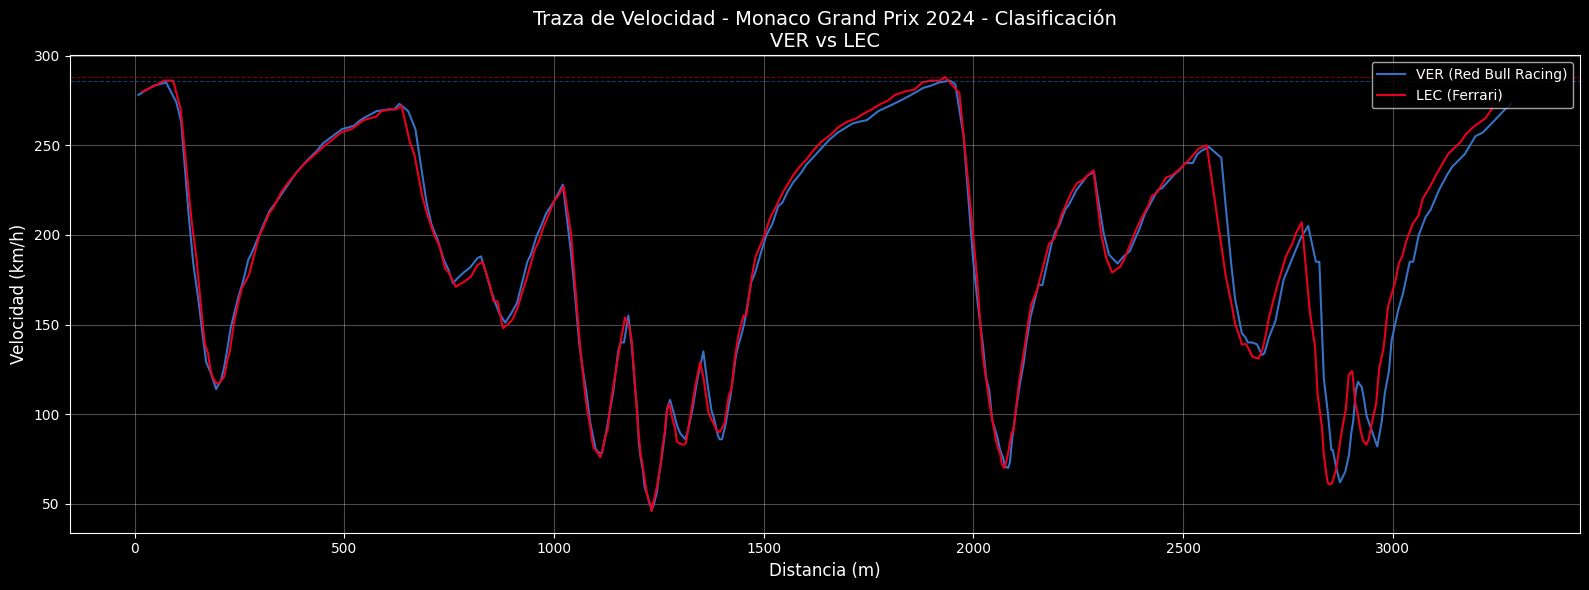


📊 Velocidad Máxima:
   VER: 286.0 km/h
   LEC: 288.0 km/h


In [10]:
# Crear gráfico de Speed Trace
fig, ax = plt.subplots(figsize=(16, 6))

ax.plot(tel_d1['Distance'], tel_d1['Speed'], color=color_d1, label=f"{DRIVER_1} ({lap_d1['Team']})", linewidth=1.5)
ax.plot(tel_d2['Distance'], tel_d2['Speed'], color=color_d2, label=f"{DRIVER_2} ({lap_d2['Team']})", linewidth=1.5)

ax.set_xlabel('Distancia (m)', fontsize=12)
ax.set_ylabel('Velocidad (km/h)', fontsize=12)
ax.set_title(f'Traza de Velocidad - {session.event["EventName"]} {YEAR} - Clasificación\n{DRIVER_1} vs {DRIVER_2}', fontsize=14)
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, alpha=0.3)

# Añadir línea de velocidad máxima
vmax_d1 = tel_d1['Speed'].max()
vmax_d2 = tel_d2['Speed'].max()
ax.axhline(y=vmax_d1, color=color_d1, linestyle='--', alpha=0.5, linewidth=0.8)
ax.axhline(y=vmax_d2, color=color_d2, linestyle='--', alpha=0.5, linewidth=0.8)

plt.tight_layout()
plt.show()

print(f"\n📊 Velocidad Máxima:")
print(f"   {DRIVER_1}: {vmax_d1:.1f} km/h")
print(f"   {DRIVER_2}: {vmax_d2:.1f} km/h")

## 4. Cálculo y Visualización del Delta Time

Muestra la diferencia acumulada en segundos entre pilotos a lo largo de la vuelta.

In [11]:
# Crear eje de distancia común para interpolación
max_distance = min(tel_d1['Distance'].max(), tel_d2['Distance'].max())
distance_common = np.linspace(0, max_distance, num=500)

# Convertir tiempo a segundos desde el inicio de la vuelta
time_d1 = (tel_d1['Time'] - tel_d1['Time'].iloc[0]).dt.total_seconds().values
time_d2 = (tel_d2['Time'] - tel_d2['Time'].iloc[0]).dt.total_seconds().values

# Interpolar tiempos al eje común
time_d1_interp = np.interp(distance_common, tel_d1['Distance'].values, time_d1)
time_d2_interp = np.interp(distance_common, tel_d2['Distance'].values, time_d2)

# Calcular delta (positivo = D2 más lento, negativo = D2 más rápido)
delta = time_d2_interp - time_d1_interp

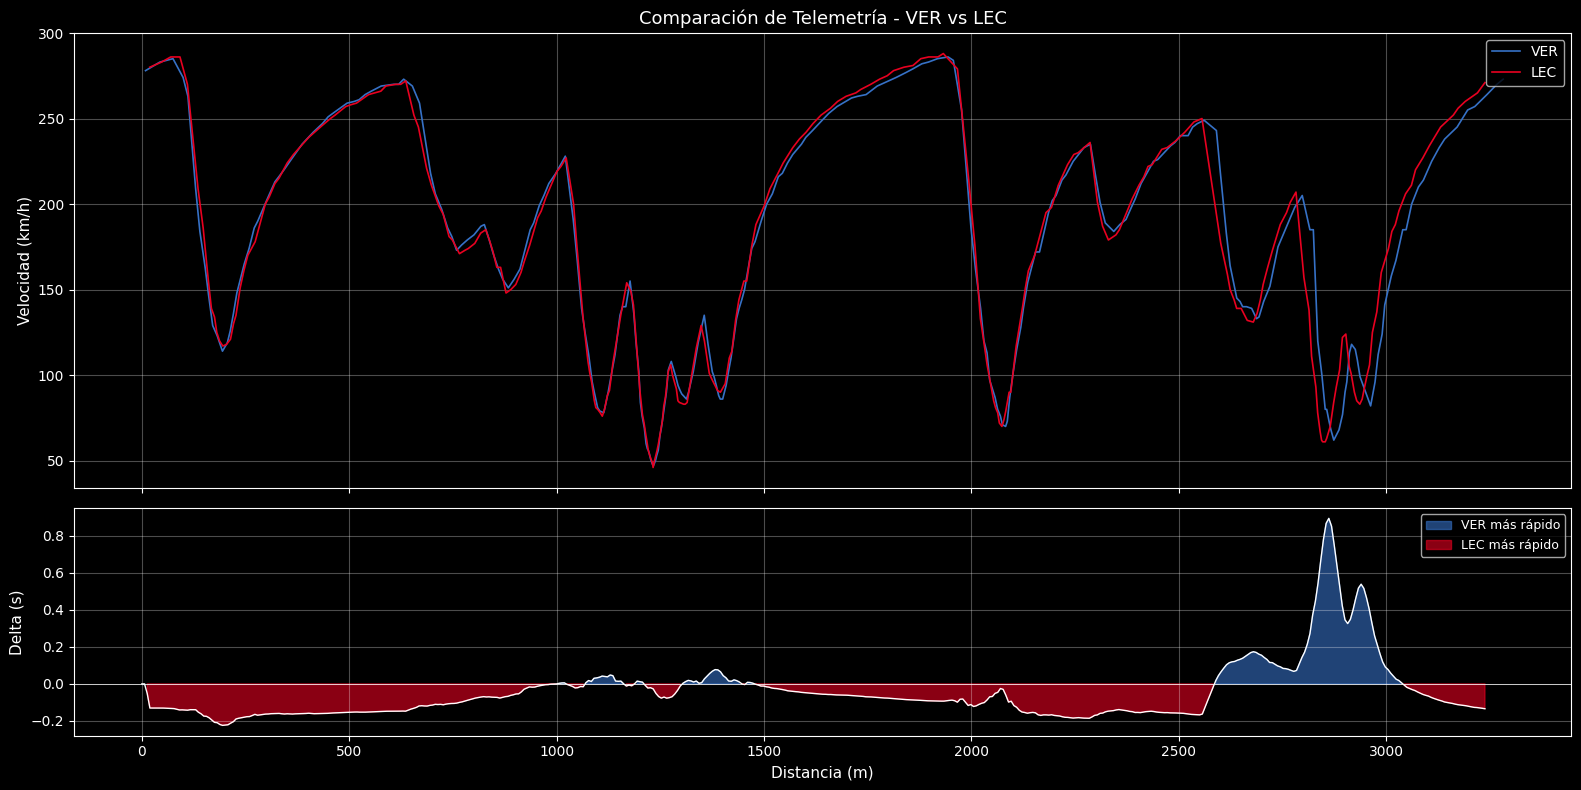


📊 Delta Final: -0.134s
   ✅ LEC más rápido


In [12]:
# Gráfico de Delta Time
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 8), sharex=True, height_ratios=[2, 1])

# Speed Trace en el panel superior
ax1.plot(tel_d1['Distance'], tel_d1['Speed'], color=color_d1, label=DRIVER_1, linewidth=1.2)
ax1.plot(tel_d2['Distance'], tel_d2['Speed'], color=color_d2, label=DRIVER_2, linewidth=1.2)
ax1.set_ylabel('Velocidad (km/h)', fontsize=11)
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)
ax1.set_title(f'Comparación de Telemetría - {DRIVER_1} vs {DRIVER_2}', fontsize=13)

# Delta en el panel inferior
ax2.fill_between(distance_common, delta, 0, where=(delta >= 0), color=color_d1, alpha=0.6, label=f'{DRIVER_1} más rápido')
ax2.fill_between(distance_common, delta, 0, where=(delta < 0), color=color_d2, alpha=0.6, label=f'{DRIVER_2} más rápido')
ax2.plot(distance_common, delta, color='white', linewidth=1)
ax2.axhline(y=0, color='white', linestyle='-', linewidth=0.5)
ax2.set_xlabel('Distancia (m)', fontsize=11)
ax2.set_ylabel('Delta (s)', fontsize=11)
ax2.legend(loc='upper right', fontsize=9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n📊 Delta Final: {delta[-1]:.3f}s")
print(f"   {'✅ ' + DRIVER_1 + ' más rápido' if delta[-1] > 0 else '✅ ' + DRIVER_2 + ' más rápido'}")

## 5. Mapa del Circuito con Mini-Sectores

Visualización del circuito coloreado por velocidad o comparación de pilotos.

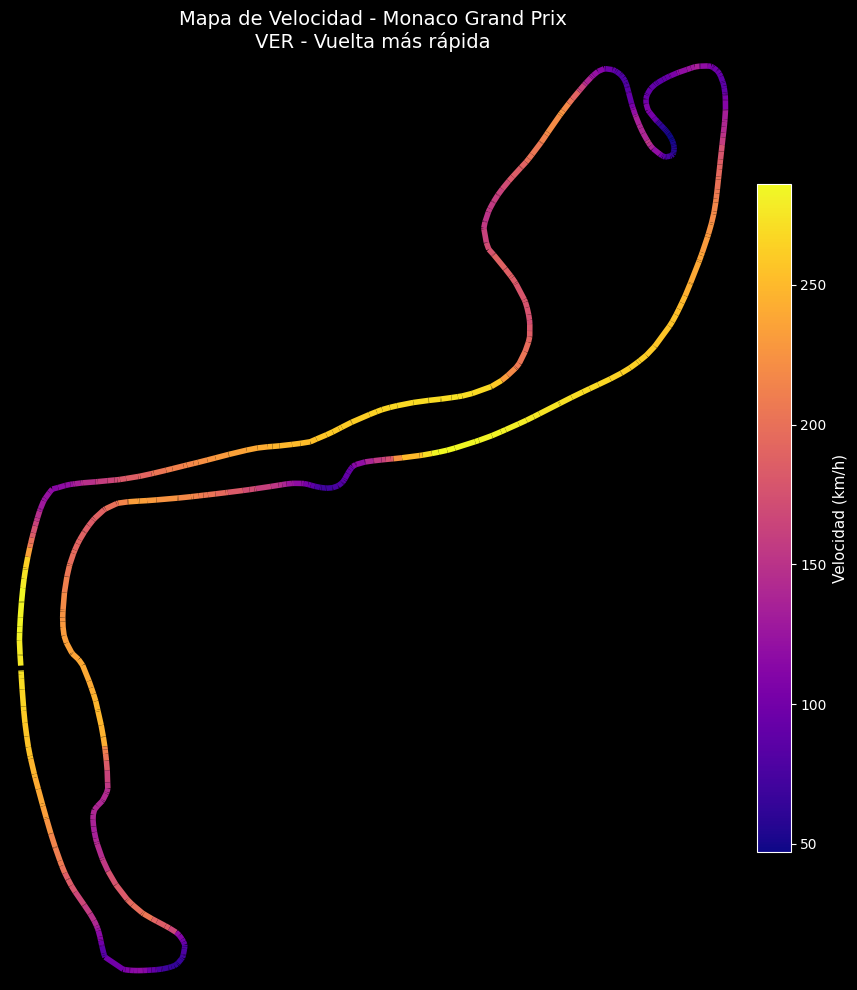

In [13]:
# Obtener posición del coche para el mapa
pos_d1 = lap_d1.get_telemetry()

# Preparar datos para LineCollection
x = pos_d1['X'].values
y = pos_d1['Y'].values
speed = pos_d1['Speed'].values

# Crear segmentos de línea
points = np.array([x, y]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)

# Crear mapa coloreado por velocidad
fig, ax = plt.subplots(figsize=(12, 10))

# Normalizar velocidad para colormap
norm = plt.Normalize(speed.min(), speed.max())
cmap = colormaps['plasma']

lc = LineCollection(segments, cmap=cmap, norm=norm, linewidth=4)
lc.set_array(speed)
line = ax.add_collection(lc)

# Configurar ejes
ax.set_xlim(x.min() - 100, x.max() + 100)
ax.set_ylim(y.min() - 100, y.max() + 100)
ax.set_aspect('equal')
ax.axis('off')

# Colorbar
cbar = fig.colorbar(line, ax=ax, orientation='vertical', fraction=0.03, pad=0.02)
cbar.set_label('Velocidad (km/h)', fontsize=11)

ax.set_title(f'Mapa de Velocidad - {session.event["EventName"]}\n{DRIVER_1} - Vuelta más rápida', fontsize=14)

plt.tight_layout()
plt.show()

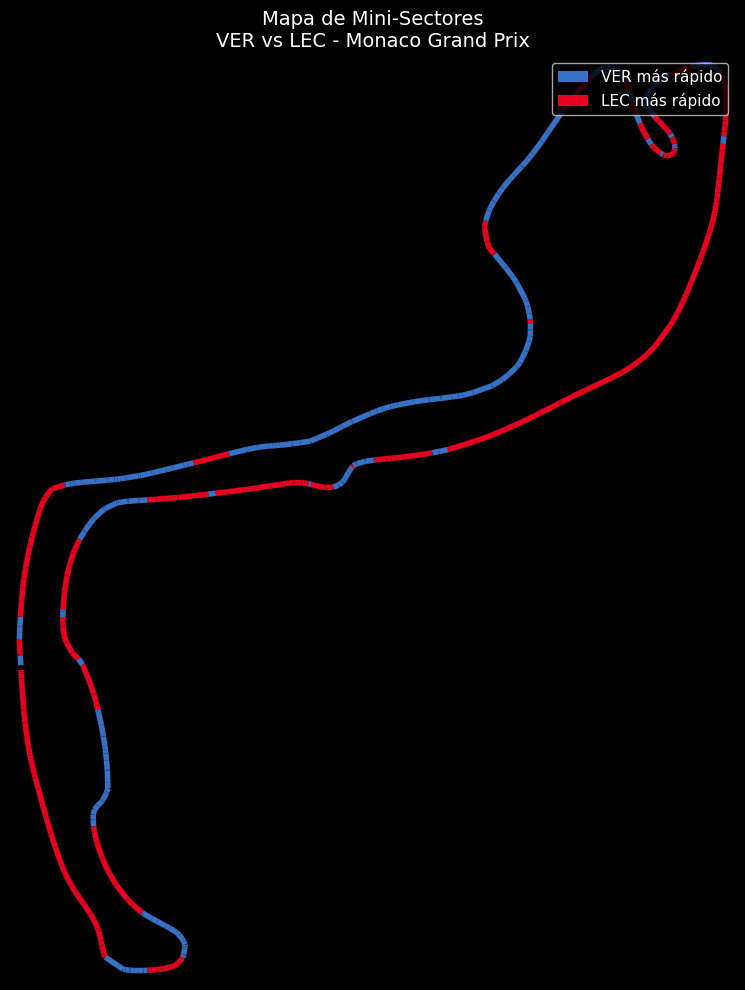

In [14]:
# Mapa de Mini-Sectores: Comparación entre pilotos
pos_d1 = lap_d1.get_telemetry()
pos_d2 = lap_d2.get_telemetry()

# Interpolar velocidad de D2 a las posiciones de D1
speed_d1 = pos_d1['Speed'].values
distance_d1 = pos_d1['Distance'].values
speed_d2_interp = np.interp(distance_d1, pos_d2['Distance'].values, pos_d2['Speed'].values)

# Determinar quién es más rápido en cada punto
faster = np.where(speed_d1 >= speed_d2_interp, 1, -1)

# Crear mapa
x = pos_d1['X'].values
y = pos_d1['Y'].values

points = np.array([x, y]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)

fig, ax = plt.subplots(figsize=(12, 10))

# Colormap personalizado: D1 color vs D2 color
from matplotlib.colors import ListedColormap
cmap_custom = ListedColormap([color_d2, color_d1])
norm = plt.Normalize(-1, 1)

lc = LineCollection(segments, cmap=cmap_custom, norm=norm, linewidth=4)
lc.set_array(faster)
ax.add_collection(lc)

ax.set_xlim(x.min() - 100, x.max() + 100)
ax.set_ylim(y.min() - 100, y.max() + 100)
ax.set_aspect('equal')
ax.axis('off')

# Leyenda manual
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=color_d1, label=f'{DRIVER_1} más rápido'),
    Patch(facecolor=color_d2, label=f'{DRIVER_2} más rápido')
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=11)

ax.set_title(f'Mapa de Mini-Sectores\n{DRIVER_1} vs {DRIVER_2} - {session.event["EventName"]}', fontsize=14)

plt.tight_layout()
plt.show()

## 6. Análisis de Inputs del Piloto

Visualización de acelerador, freno y técnica de conducción.

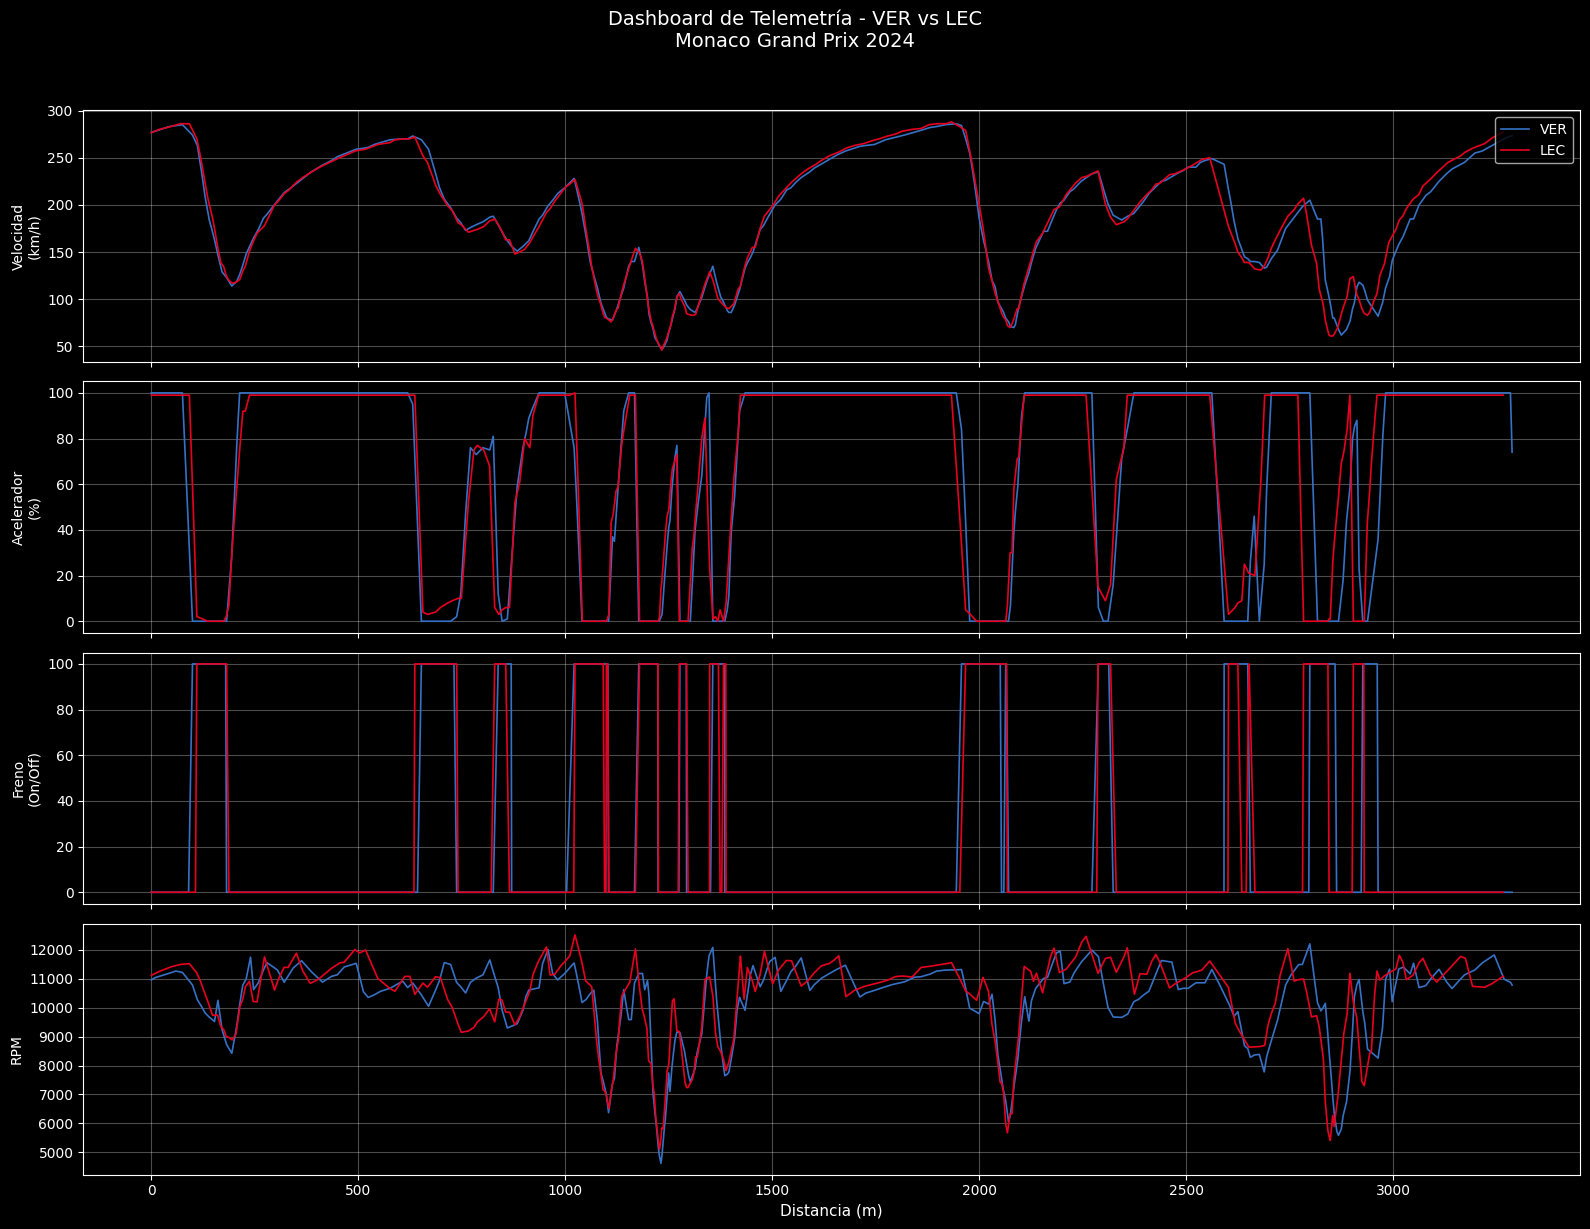

In [15]:
# Crear dashboard de inputs
fig, axes = plt.subplots(4, 1, figsize=(16, 12), sharex=True)

# Obtener telemetría completa
tel_full_d1 = lap_d1.get_telemetry()
tel_full_d2 = lap_d2.get_telemetry()

# Panel 1: Velocidad
axes[0].plot(tel_full_d1['Distance'], tel_full_d1['Speed'], color=color_d1, label=DRIVER_1, linewidth=1.2)
axes[0].plot(tel_full_d2['Distance'], tel_full_d2['Speed'], color=color_d2, label=DRIVER_2, linewidth=1.2)
axes[0].set_ylabel('Velocidad\n(km/h)', fontsize=10)
axes[0].legend(loc='upper right')
axes[0].grid(True, alpha=0.3)

# Panel 2: Acelerador
axes[1].plot(tel_full_d1['Distance'], tel_full_d1['Throttle'], color=color_d1, linewidth=1.2)
axes[1].plot(tel_full_d2['Distance'], tel_full_d2['Throttle'], color=color_d2, linewidth=1.2)
axes[1].set_ylabel('Acelerador\n(%)', fontsize=10)
axes[1].set_ylim(-5, 105)
axes[1].grid(True, alpha=0.3)

# Panel 3: Freno
axes[2].plot(tel_full_d1['Distance'], tel_full_d1['Brake'].astype(int) * 100, color=color_d1, linewidth=1.2)
axes[2].plot(tel_full_d2['Distance'], tel_full_d2['Brake'].astype(int) * 100, color=color_d2, linewidth=1.2)
axes[2].set_ylabel('Freno\n(On/Off)', fontsize=10)
axes[2].set_ylim(-5, 105)
axes[2].grid(True, alpha=0.3)

# Panel 4: RPM
axes[3].plot(tel_full_d1['Distance'], tel_full_d1['RPM'], color=color_d1, linewidth=1.2)
axes[3].plot(tel_full_d2['Distance'], tel_full_d2['RPM'], color=color_d2, linewidth=1.2)
axes[3].set_ylabel('RPM', fontsize=10)
axes[3].set_xlabel('Distancia (m)', fontsize=11)
axes[3].grid(True, alpha=0.3)

fig.suptitle(f'Dashboard de Telemetría - {DRIVER_1} vs {DRIVER_2}\n{session.event["EventName"]} {YEAR}', fontsize=14, y=1.02)

plt.tight_layout()
plt.show()

## 7. Mapa de Marchas (Gear Map)

Visualización de las marchas utilizadas en cada punto del circuito.

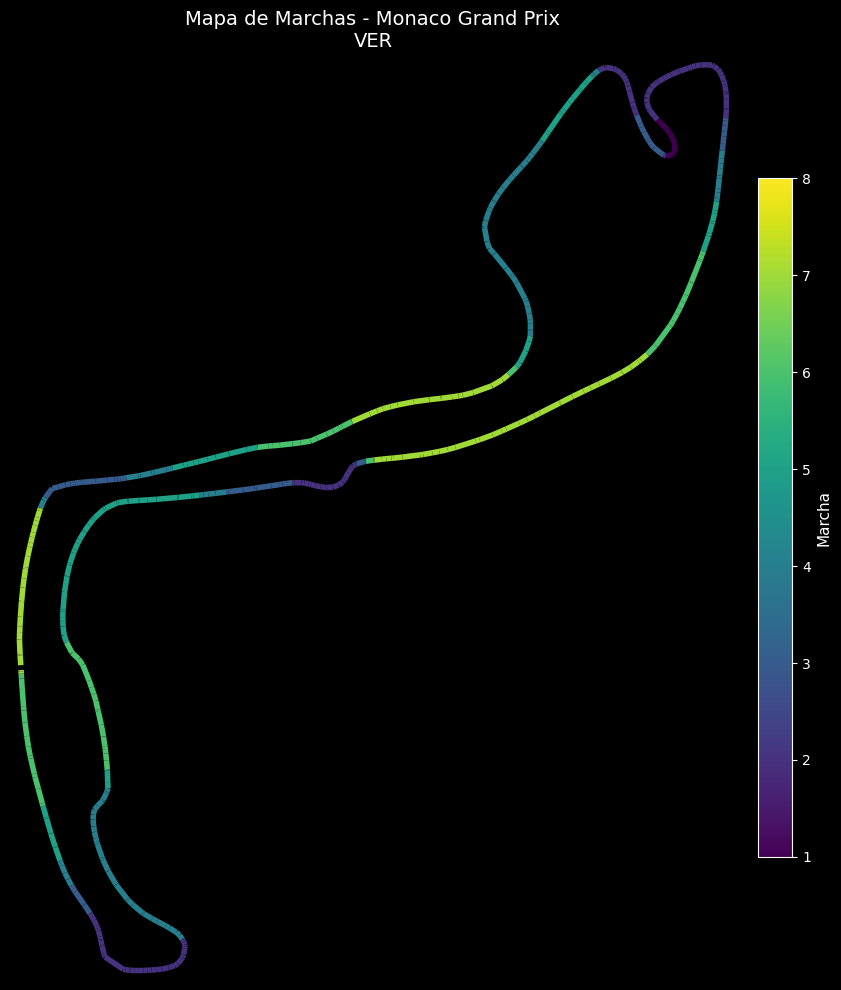

In [16]:
# Mapa de marchas
gear = tel_full_d1['nGear'].values
x = tel_full_d1['X'].values
y = tel_full_d1['Y'].values

points = np.array([x, y]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)

fig, ax = plt.subplots(figsize=(12, 10))

# Colormap para marchas (1-8)
cmap = colormaps['viridis']
norm = plt.Normalize(1, 8)

lc = LineCollection(segments, cmap=cmap, norm=norm, linewidth=4)
lc.set_array(gear)
line = ax.add_collection(lc)

ax.set_xlim(x.min() - 100, x.max() + 100)
ax.set_ylim(y.min() - 100, y.max() + 100)
ax.set_aspect('equal')
ax.axis('off')

# Colorbar con marchas discretas
cbar = fig.colorbar(line, ax=ax, orientation='vertical', fraction=0.03, pad=0.02, ticks=range(1, 9))
cbar.set_label('Marcha', fontsize=11)

ax.set_title(f'Mapa de Marchas - {session.event["EventName"]}\n{DRIVER_1}', fontsize=14)

plt.tight_layout()
plt.show()

## 8. Análisis de Degradación de Neumáticos (Sesión de Carrera)

Para este análisis necesitamos datos de carrera. Cargaremos una sesión de carrera para analizar la evolución de tiempos.

In [17]:
# Cargar sesión de carrera
print("🏁 Cargando datos de carrera para análisis de degradación...")
race = fastf1.get_session(YEAR, GP, 'R')
race.load()

print(f"✅ Carrera cargada: {race.event['EventName']}")

core           INFO 	Loading data for Monaco Grand Prix - Race [v3.7.0]
req            INFO 	No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...


🏁 Cargando datos de carrera para análisis de degradación...


req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for lap_count. Loading data...
_api           INFO 	Fetching lap count data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for _extended_timing_data. Loading data...
_api           INFO 	Fetching timing data...
_api           INFO 	Parsing timing data...
req            INFO 	Data has been written to cache!

✅ Carrera cargada: Monaco Grand Prix


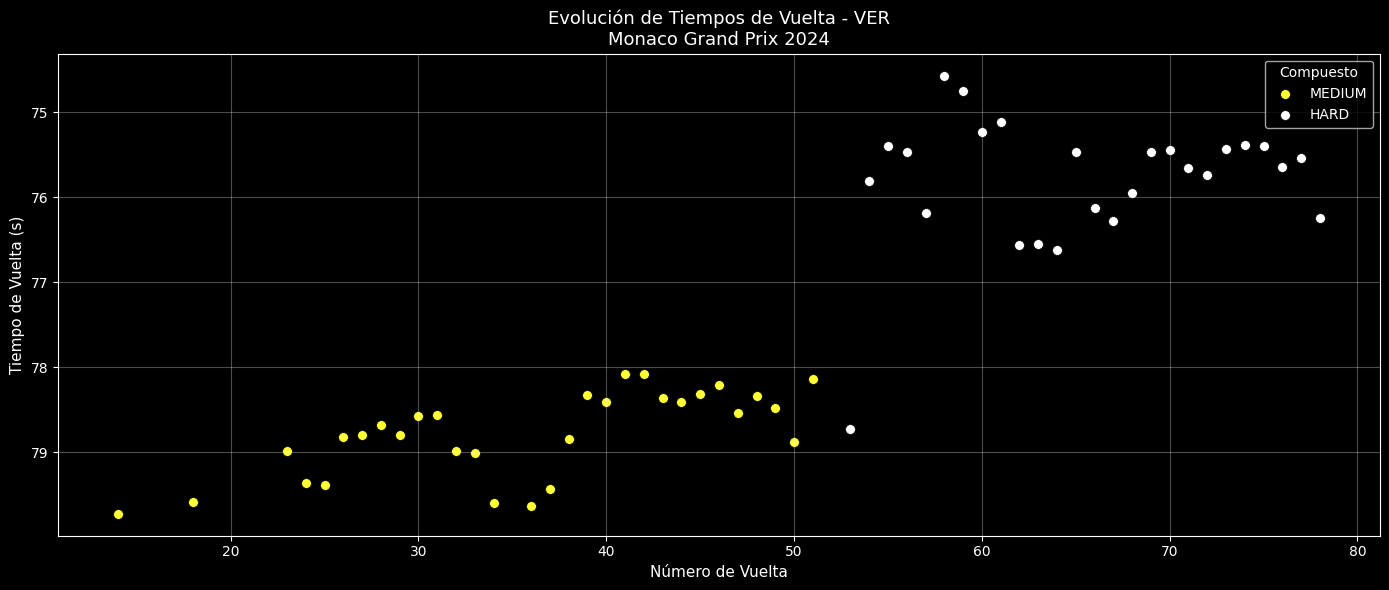

In [18]:
# Obtener vueltas de un piloto específico
driver_laps = race.laps.pick_driver(DRIVER_1).pick_quicklaps().reset_index()

# Convertir tiempos a segundos
driver_laps['LapTimeSeconds'] = driver_laps['LapTime'].dt.total_seconds()

# Filtrar vueltas válidas (sin pit stops extremos)
median_time = driver_laps['LapTimeSeconds'].median()
driver_laps = driver_laps[driver_laps['LapTimeSeconds'] < median_time * 1.1]

# Crear gráfico de evolución de tiempos
fig, ax = plt.subplots(figsize=(14, 6))

# Colorear por compuesto de neumático
compound_colors = {'SOFT': '#FF3333', 'MEDIUM': '#FFFF33', 'HARD': '#FFFFFF', 'INTERMEDIATE': '#33FF33', 'WET': '#3333FF'}

for compound in driver_laps['Compound'].unique():
    mask = driver_laps['Compound'] == compound
    color = compound_colors.get(compound, '#888888')
    ax.scatter(driver_laps.loc[mask, 'LapNumber'], 
               driver_laps.loc[mask, 'LapTimeSeconds'],
               c=color, s=50, label=compound, edgecolors='black', linewidth=0.5)

ax.set_xlabel('Número de Vuelta', fontsize=11)
ax.set_ylabel('Tiempo de Vuelta (s)', fontsize=11)
ax.set_title(f'Evolución de Tiempos de Vuelta - {DRIVER_1}\n{race.event["EventName"]} {YEAR}', fontsize=13)
ax.legend(title='Compuesto', loc='upper right')
ax.grid(True, alpha=0.3)

# Invertir eje Y para que tiempos más rápidos estén arriba
ax.invert_yaxis()

plt.tight_layout()
plt.show()

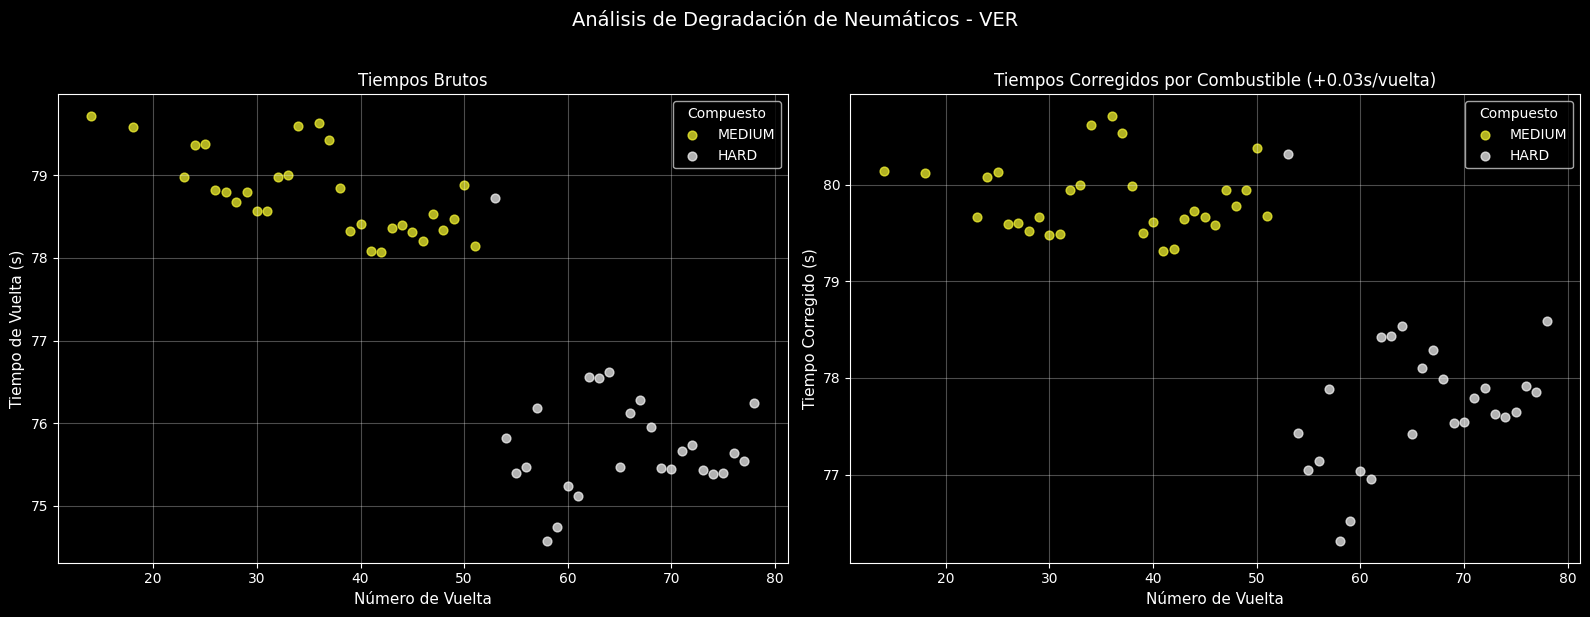

In [19]:
# Análisis de degradación por stint
# Factor de corrección de combustible: ~0.03s por vuelta
FUEL_CORRECTION = 0.03

# Aplicar corrección
driver_laps['LapTimeCorrected'] = driver_laps['LapTimeSeconds'] + (driver_laps['LapNumber'] * FUEL_CORRECTION)

# Gráfico comparativo
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Sin corrección
for compound in driver_laps['Compound'].unique():
    mask = driver_laps['Compound'] == compound
    color = compound_colors.get(compound, '#888888')
    ax1.scatter(driver_laps.loc[mask, 'LapNumber'], 
                driver_laps.loc[mask, 'LapTimeSeconds'],
                c=color, s=40, label=compound, alpha=0.7)

ax1.set_xlabel('Número de Vuelta', fontsize=11)
ax1.set_ylabel('Tiempo de Vuelta (s)', fontsize=11)
ax1.set_title('Tiempos Brutos', fontsize=12)
ax1.legend(title='Compuesto')
ax1.grid(True, alpha=0.3)

# Con corrección de combustible
for compound in driver_laps['Compound'].unique():
    mask = driver_laps['Compound'] == compound
    color = compound_colors.get(compound, '#888888')
    ax2.scatter(driver_laps.loc[mask, 'LapNumber'], 
                driver_laps.loc[mask, 'LapTimeCorrected'],
                c=color, s=40, label=compound, alpha=0.7)

ax2.set_xlabel('Número de Vuelta', fontsize=11)
ax2.set_ylabel('Tiempo Corregido (s)', fontsize=11)
ax2.set_title(f'Tiempos Corregidos por Combustible (+{FUEL_CORRECTION}s/vuelta)', fontsize=12)
ax2.legend(title='Compuesto')
ax2.grid(True, alpha=0.3)

fig.suptitle(f'Análisis de Degradación de Neumáticos - {DRIVER_1}', fontsize=14, y=1.02)

plt.tight_layout()
plt.show()

## 9. Resumen de Métricas Clave

In [20]:
# Resumen estadístico
print("=" * 60)
print(f"📊 RESUMEN DE ANÁLISIS - {session.event['EventName']} {YEAR}")
print("=" * 60)

print(f"\n🏎️ {DRIVER_1}:")
print(f"   • Mejor vuelta: {lap_d1['LapTime']}")
print(f"   • Velocidad máxima: {tel_full_d1['Speed'].max():.1f} km/h")
print(f"   • Velocidad promedio: {tel_full_d1['Speed'].mean():.1f} km/h")
print(f"   • RPM máximo: {tel_full_d1['RPM'].max():,.0f}")

print(f"\n🏎️ {DRIVER_2}:")
print(f"   • Mejor vuelta: {lap_d2['LapTime']}")
print(f"   • Velocidad máxima: {tel_full_d2['Speed'].max():.1f} km/h")
print(f"   • Velocidad promedio: {tel_full_d2['Speed'].mean():.1f} km/h")
print(f"   • RPM máximo: {tel_full_d2['RPM'].max():,.0f}")

print(f"\n⏱️ Delta Total: {abs(delta[-1]):.3f}s a favor de {DRIVER_1 if delta[-1] > 0 else DRIVER_2}")
print("=" * 60)

📊 RESUMEN DE ANÁLISIS - Monaco Grand Prix 2024

🏎️ VER:
   • Mejor vuelta: 0 days 00:01:10.567000
   • Velocidad máxima: 286.0 km/h
   • Velocidad promedio: 169.2 km/h
   • RPM máximo: 12,202

🏎️ LEC:
   • Mejor vuelta: 0 days 00:01:10.270000
   • Velocidad máxima: 288.0 km/h
   • Velocidad promedio: 166.7 km/h
   • RPM máximo: 12,510

⏱️ Delta Total: 0.134s a favor de LEC
